# 第54篇 | 交叉验证与超参数调优：网格搜索 + 贝叶斯优化

> 这是「数据分析从入门到精通」系列的第 54 篇。模型评估学会了，这篇来聊如何把模型调到最优状态——交叉验证防止过拟合，网格搜索和贝叶斯优化帮你找到最佳超参数。调参是门学问，这篇教你科学地调。

嗨，我是小荷～ 前面学了很多算法，但模型性能好不好，很大程度上取决于参数设置。今天来学**如何科学地调参**，让模型发挥最佳性能！

---

## 一、为什么需要交叉验证？

**交叉验证（Cross-Validation）** 的核心目的只有一句话：**用有限的数据，换取对模型泛化能力最准确、最稳定的评估。**

如果你只把数据简单地拆分为“训练集”和“测试集”（即 Holdout 方法），很容易陷入机器学习的几个重大陷阱。以下是我们需要交叉验证的核心原因：


### 1. 避免“数据划分”带来的运气成分（选择偏差）

如果只进行一次随机划分，你可能会运气很好地把“容易预测的数据”分进了测试集，导致评估分数虚高；或者反过来，测试集里全是“极端特例”，导致分数极其难看。

* **交叉验证的解决方式：** 比如在 $K$ 折交叉验证（K-fold Cross-Validation）中，数据会被均匀分成 K 份。模型会轮流把其中一份当做测试集，其余 $K-1$ 份当做训练集，整整轮转 $K$ 次。
* **结果：** 最终的性能评估是这 $K$ 次分数的平均值。这极大地消除了单次划分的随机性，让评估结果更具说服力。

---

### 2. 最大化利用有限的数据

在实际项目中，获取高质量的标注数据成本极高。如果你为了保证测试效果，硬生生切出 30% 的数据作为测试集且永远不让模型看它，那模型就失去了用这 30% 数据来学习特征的机会。

* **交叉验证的解决方式：** 每一条数据都曾作为“训练集”帮助模型学习，也都曾作为“验证集”来检验模型。没有任何数据被浪费。

### 3. 防止对验证集“隐式过拟合”（调参陷阱）

我们在调整模型的超参数（比如决策树的深度、正则化系数）时，通常会看验证集的表现。如果一直对着固定的验证集调整参数，模型就会逐渐“迎合”这个验证集的特定分布。这就叫**隐式过拟合**——模型虽然在验证集上分数很高，但一碰到真正全新的测试数据就原形毕露。

* **交叉验证的解决方式：** 因为验证集在每一次循环中都在发生变化，模型无法通过“作弊”去迎合某一个固定的验证集，从而逼迫我们选出真正具有普适性的超参数。


### 4. 提供评估的稳定性和置信度

普通的划分只能给你一个孤零零的分数（例如：准确率 85%）。但你不知道这个 85% 是偶然达到的，还是模型的真实水平。

* **交叉验证的解决方式：** 它会给你 K 个不同的分数。通过这组分数，你不仅能计算**平均值**，还能计算**标准差（方差）**。
* 如果 $K$ 次的分数分别是 `84%, 85%, 85%, 86%, 85%`，说明模型非常**稳定**。
* 如果分数是 `60%, 95%, 70%, 90%, 85%`，说明模型对数据的划分极其敏感，泛化能力很差，容易产生**高方差（Variance）**。

### 总结

可以将普通的训练集/测试集划分比作“期末一考定终身”**，运气成分很大；而交叉验证则是**“多次模拟考试取平均分”，能真正压榨出每一滴数据的价值，测出模型的真实底细。


---

## 二、K折交叉验证

**原理**：把数据分成K份，轮流用K-1份训练，1份验证，最后取平均。

下面我们写代码生成一些测试数据，然后对比一下一次随机划分和5折交叉验证的关键指标。

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import (train_test_split, cross_val_score, 
                                     cross_validate, KFold, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, make_scorer,f1_score  
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("交叉验证与超参数调优")

# 生成数据
np.random.seed(42)
X, y = make_classification(
    n_samples=500,    # 总样本数
    n_features=10,   # 总特征数（维度）
    n_informative=5, # 有效特征（真正有用的）
    n_redundant=2,   # 冗余特征（没用、干扰项）
    n_classes=2,     # 二分类（0 和 1）
    random_state=42  # 固定随机种子，结果可复现
)

print(f"数据形状: {X.shape}")
print(f"类别分布: {np.bincount(y)}")

# 1. 划分数据集：20% 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 训练随机森林
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 3. 预测
y_pred = model.predict(X_test)

# 4. 输出指标
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*50)
print(f"测试集准确率: {acc:.4f}")
print(f"测试集 F1 分数: {f1:.4f}")
print("="*50)


交叉验证与超参数调优
数据形状: (500, 10)
类别分布: [249 251]

测试集准确率: 0.8600
测试集 F1 分数: 0.8511


In [2]:
# 普通K折交叉验证
from sklearn.model_selection import KFold

print("\n5折交叉验证演示:")
print("-" * 40)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold = 1

for train_idx, val_idx in kf.split(X):
    print(f"折 {fold}: 训练集 {len(train_idx)}个, 验证集 {len(val_idx)}个")
    fold += 1

# 使用交叉验证评估模型
rf = RandomForestClassifier(n_estimators=50, random_state=42)

# 简单交叉验证
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\n5折交叉验证准确率:")
print(f"  每折结果: {cv_scores.round(4)}")
print(f"  平均值: {cv_scores.mean():.4f}")
print(f"  标准差: {cv_scores.std():.4f}")

# 更详细的交叉验证结果
cv_results = cross_validate(rf, X, y, cv=5, 
                           scoring=['accuracy', 'precision', 'recall', 'f1'],
                           return_train_score=True)

print(f"\n详细交叉验证结果:")
print("-" * 40)
print(f"训练准确率: {cv_results['train_accuracy'].mean():.4f} (+/- {cv_results['train_accuracy'].std():.4f})")
print(f"验证准确率: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"验证F1:     {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")



5折交叉验证演示:
----------------------------------------
折 1: 训练集 400个, 验证集 100个
折 2: 训练集 400个, 验证集 100个
折 3: 训练集 400个, 验证集 100个
折 4: 训练集 400个, 验证集 100个
折 5: 训练集 400个, 验证集 100个

5折交叉验证准确率:
  每折结果: [0.93 0.96 0.9  0.84 0.93]
  平均值: 0.9120
  标准差: 0.0407

详细交叉验证结果:
----------------------------------------
训练准确率: 1.0000 (+/- 0.0000)
验证准确率: 0.9120 (+/- 0.0407)
验证F1:     0.9100 (+/- 0.0435)


可以看到，交叉验证准确率（0.91） > 单次划分（0.86），说明单次划分运气不好，模型真实能力更强。

单次数据集划分的评估结果存在偶然性，而5 折交叉验证通过多次训练测试，得到的平均准确率（0.9120）更能反映模型真实性能，且标准差较小，说明模型稳定性良好。

数字结果看完了，画图看看折数 K 对验证结果的影响：


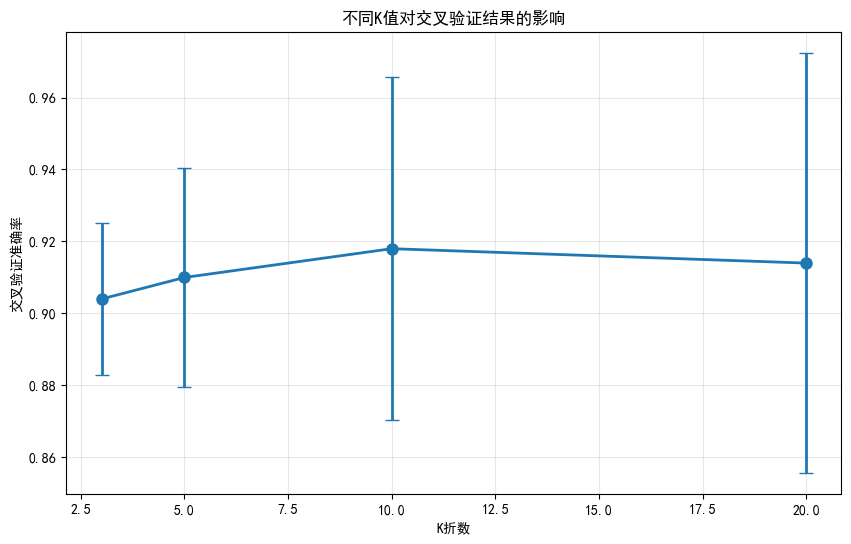


K值选择建议:
----------------------------------------
• K=5: 最常用，平衡计算量和稳定性
• K=10: 更稳定，但计算量增加
• 留一法(LOO): K=样本数，最准确但极慢


In [17]:
# 可视化不同K值的影响
k_values = [3, 5, 10, 20]
cv_means = []
cv_stds = []

for k in k_values:
    scores = cross_val_score(rf, X, y, cv=k)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

plt.figure(figsize=(10, 6))
plt.errorbar(k_values, cv_means, yerr=cv_stds, marker='o', capsize=5, 
            linewidth=2, markersize=8)
plt.xlabel('K折数')
plt.ylabel('交叉验证准确率')
plt.title('不同K值对交叉验证结果的影响')
plt.grid(True, alpha=0.3)
plt.show()

print("\nK值选择建议:")
print("-" * 40)
print("• K=5: 最常用，平衡计算量和稳定性")
print("• K=10: 更稳定，但计算量增加")
print("• 留一法(LOO): K=样本数，最准确但极慢")


---

## 三、分层K折交叉验证

**问题**：普通K折可能导致每折类别分布不一致（尤其类别不平衡时）。

**解决方案**：分层K折（StratifiedKFold），保证每折类别比例相同,保证每一轮训练、测试集都不偏不倚。不平衡数据必须用。

下面我们用代码直观对比普通 K 折 和 分层 K 折的区别，专门用不平衡数据演示。

In [4]:
from sklearn.model_selection import StratifiedKFold

print("\n分层K折 vs 普通K折:")
print("=" * 60)

# 生成不平衡数据
X_imb, y_imb = make_classification(n_samples=500, n_features=10, 
                                   weights=[0.9, 0.1], random_state=42)
print(f"数据类别分布: {np.bincount(y_imb)}")

# 普通K折
print("\n普通K折的类别分布:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X_imb), 1):
    y_val = y_imb[val_idx]
    print(f"  折{fold}: 正例比例 = {y_val.mean():.2%}")

# 分层K折
print("\n分层K折的类别分布:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(skf.split(X_imb, y_imb), 1):
    y_val = y_imb[val_idx]
    print(f"  折{fold}: 正例比例 = {y_val.mean():.2%}")

# 对比性能
print("\n性能对比:")
print("-" * 40)
rf = RandomForestClassifier(n_estimators=50, random_state=42)

kf_scores = cross_val_score(rf, X_imb, y_imb, cv=KFold(n_splits=5, shuffle=True, random_state=42))
skf_scores = cross_val_score(rf, X_imb, y_imb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

print(f"普通K折:  {kf_scores.mean():.4f} (+/- {kf_scores.std():.4f})")
print(f"分层K折:  {skf_scores.mean():.4f} (+/- {skf_scores.std():.4f})")
print(f"\n分层K折更稳定，类别不平衡时务必使用！")



分层K折 vs 普通K折:
数据类别分布: [448  52]

普通K折的类别分布:
  折1: 正例比例 = 10.00%
  折2: 正例比例 = 8.00%
  折3: 正例比例 = 6.00%
  折4: 正例比例 = 10.00%
  折5: 正例比例 = 18.00%

分层K折的类别分布:
  折1: 正例比例 = 11.00%
  折2: 正例比例 = 11.00%
  折3: 正例比例 = 10.00%
  折4: 正例比例 = 10.00%
  折5: 正例比例 = 10.00%

性能对比:
----------------------------------------
普通K折:  0.9520 (+/- 0.0256)
分层K折:  0.9540 (+/- 0.0150)

分层K折更稳定，类别不平衡时务必使用！


---

## 四、网格搜索：暴力穷举找最优

网格搜索（Grid Search）是一种穷举式超参数优化方法，通过遍历用户指定的所有超参数组合，利用交叉验证评估每组参数的性能，最终自动筛选出最优超参数，使模型达到最佳效果。

下面我们用网格搜索（Grid Search）对随机森林模型进行超参数优化，遍历 36 种超参数组合，通过 5 折交叉验证评估每组参数性能，自动输出最优参数与最优得分，并展示性能最佳的前五组参数，实现模型的自动化调优。

In [5]:
print("\n" + "="*60)
print("🔍 网格搜索 (Grid Search)")
print("="*60)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],  # 树的数量
    'max_depth': [3, 5, 7, None],    # 树的最大深度
    'min_samples_split': [2, 5, 10]  # 分裂所需最小样本数
}

print(f"参数网格:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()]) # 计算总共有多少种参数组合，3 × 4 × 3 = 36 种组合
print(f"\n总组合数: {total_combinations}")

# 执行网格搜索
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,  # 使用所有CPU核心
    verbose=1
)

print("\n开始网格搜索...")
grid_search.fit(X, y)

print(f"\n最优参数:")
print("-" * 40)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n最优交叉验证得分: {grid_search.best_score_:.4f}")

# 查看所有结果
results_df = pd.DataFrame(grid_search.cv_results_)
print(f"\nTop 5 参数组合:")
print("-" * 40)
top5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
for idx, row in top5.iterrows():
    print(f"  {row['params']}")
    print(f"    得分: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")



🔍 网格搜索 (Grid Search)
参数网格:
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 7, None]
  min_samples_split: [2, 5, 10]

总组合数: 36

开始网格搜索...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

最优参数:
----------------------------------------
  max_depth: None
  min_samples_split: 5
  n_estimators: 50

最优交叉验证得分: 0.9180

Top 5 参数组合:
----------------------------------------
  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
    得分: 0.9180 (+/- 0.0397)
  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
    得分: 0.9160 (+/- 0.0273)
  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
    得分: 0.9160 (+/- 0.0265)
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
    得分: 0.9140 (+/- 0.0338)
  {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
    得分: 0.9140 (+/- 0.0206)


文字结果不够直观，画热力图看看参数组合的得分分布：


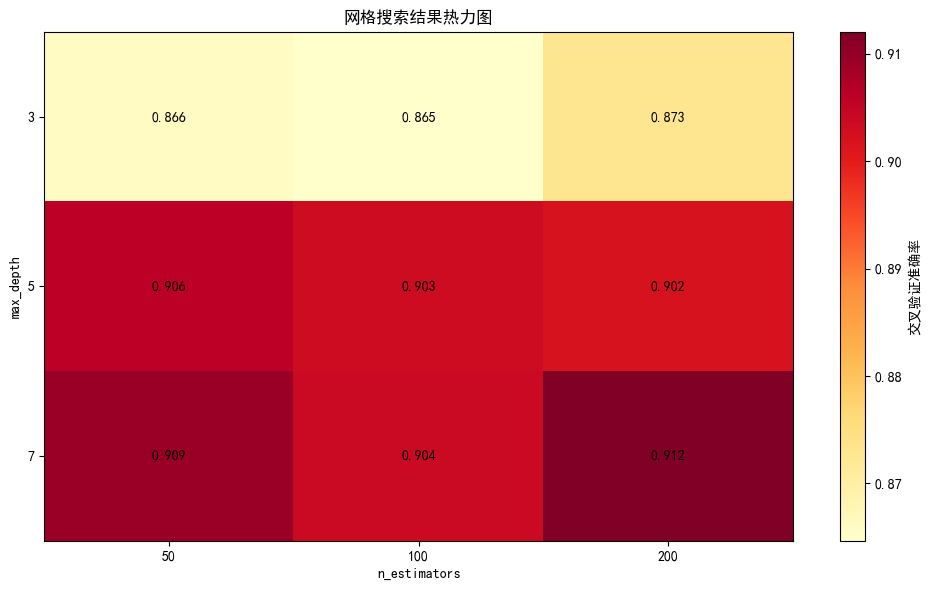

In [6]:
# 可视化网格搜索结果
# 提取n_estimators和max_depth的结果
pivot_data = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns = plt.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(sns, label='交叉验证准确率')

plt.xticks(range(len(pivot_data.columns)), pivot_data.columns)
plt.yticks(range(len(pivot_data.index)), pivot_data.index)

plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.title('网格搜索结果热力图')

# 添加数值标注
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        plt.text(j, i, f'{pivot_data.values[i, j]:.3f}',
                ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()


热力图可视化展示了 ** 树深度（max_depth）与树数量（n_estimators）** 对模型性能的影响，颜色越深代表交叉验证准确率越高。通过热力图可以快速定位最优参数组合，直观观察超参数与模型性能的关系。

---

## 五、随机搜索：更高效的探索

随机搜索是一种高效的超参数优化方法，通过随机采样候选参数组合进行验证，相比网格搜索更节省计算资源，在高维超参数空间中效率更高，是大规模模型调优的常用方法。

**问题**：网格搜索在参数空间很大时，所有组合挨个试，计算量爆炸。

**解决方案**：随机搜索，随机采样参数组合，随机选一部分组合试，通常更快找到好参数。

下面我们用随机搜索给随机森林自动调参，不试全部组合，只随机试 50 组，更快找到最优模型。

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("\n" + "="*60)
print("🎲 随机搜索 (Random Search)")
print("="*60)

# 定义参数分布
param_distributions = {
    'n_estimators': randint(50, 500),  # 树数量：50~500 随机
    'max_depth': [3, 5, 7, 10, 15, 20, None], # 树深度
    'min_samples_split': randint(2, 20),  # 分裂条件随机
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

print(f"参数分布:")
for param, dist in param_distributions.items():
    print(f"  {param}: {dist}")

# 执行随机搜索
rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    rf, param_distributions,
    n_iter=50,  # 只尝试50种组合
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\n开始随机搜索...")
random_search.fit(X, y)

print(f"\n最优参数:")
print("-" * 40)
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n最优交叉验证得分: {random_search.best_score_:.4f}")

# 对比网格搜索和随机搜索
print("\n网格搜索 vs 随机搜索:")
print("-" * 40)
print(f"网格搜索: 尝试{total_combinations}种组合, 得分={grid_search.best_score_:.4f}")
print(f"随机搜索: 尝试50种组合, 得分={random_search.best_score_:.4f}")


🎲 随机搜索 (Random Search)
参数分布:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x799b88b3c350>
  max_depth: [3, 5, 7, 10, 15, 20, None]
  min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x799b86815f40>
  min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x799b88d9ecc0>
  max_features: ['sqrt', 'log2', None]

开始随机搜索...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

最优参数:
----------------------------------------
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 3
  min_samples_split: 6
  n_estimators: 356

最优交叉验证得分: 0.9100

网格搜索 vs 随机搜索:
----------------------------------------
网格搜索: 尝试36种组合, 得分=0.9180
随机搜索: 尝试50种组合, 得分=0.9100


可以看到，随机搜索用更少的尝试，找到了相近的结果。


---

## 六、贝叶斯优化：智能搜索

贝叶斯优化是一种比网格 / 随机搜索更聪明、更快、更省资源的调参方法。它是一种智能超参数搜索方法，基于概率模型推理最优参数组合，利用历史结果指导下一次搜索，比网格搜索和随机搜索更高效，能用更少的迭代次数找到更好的模型。

**原理**：根据已尝试的参数结果，预测哪些区域可能有更好的表现，智能选择下一个尝试点。

下面我们演示一下如何使用 scikit-optimize 库中的贝叶斯优化（Bayesian Optimization）方法，来自动寻找随机森林分类器（RandomForestClassifier）的最佳超参数组合。

In [24]:
print("贝叶斯优化 (Bayesian Optimization)")

# 安装和导入scikit-optimize
try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    
    # 定义搜索空间
    # 不同于网格搜索提供固定的列表，贝叶斯优化需要定义参数的概率分布或取值范围
    search_space = {
        'n_estimators': Integer(50, 500), # 整数型，在 50 到 500 之间探索
        'max_depth': Integer(3, 20), # 整数型，在 3 到 20 之间探索
        'min_samples_split': Integer(2, 20), # 整数型，在 2 到 20 之间探索
        'min_samples_leaf': Integer(1, 10), # 整数型，在 1 到 10 之间探索
        'max_features': Categorical(['sqrt', 'log2', None])  # 类别型，从 ['sqrt', 'log2', None] 这三个选项中智能选择。
    }
    
    # 执行贝叶斯优化
    rf = RandomForestClassifier(random_state=42) # 创建一个默认的 RandomForestClassifier 作为基准模型
    bayes_search = BayesSearchCV(
        rf, search_space,
        n_iter=30,  # 设置最大迭代次数为 30 次
        cv=5, # 使用 5 折交叉验证
        scoring='accuracy', # 评估指标为准确率
        n_jobs=-1, # 利用所有 CPU 核心并行计算
        random_state=42,
        verbose=1
    )
    
    print("开始贝叶斯优化...")
    # 开始训练。在这个过程中，算法会根据前几次的随机采样和历史评估结果，
    # 建立一个代理模型（如高斯过程），从而“聪明”地引导下一次去评估最有可能带来高分的参数组合。
    # 整个搜索过程总共需要进行 30*5=150次模型拟合（fits）
    bayes_search.fit(X, y)  
    
    print(f"\n最优参数:")
    print("-" * 40)
    # 遍历字典 bayes_search.best_params_，逐一展示表现最好的超参数及其对应的值
    for param, value in bayes_search.best_params_.items():
        print(f"  {param}: {value}")
    
    print(f"\n最优交叉验证得分: {bayes_search.best_score_:.4f}")
    
    bayes_available = True
    
except ImportError:
    print("scikit-optimize未安装，跳过贝叶斯优化演示")
    print("安装命令: pip install scikit-optimize")
    bayes_available = False


贝叶斯优化 (Bayesian Optimization)
开始贝叶斯优化...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds

如果使用传统的网格搜索（Grid Search），假设你有 100 种参数组合，那么日志就会变成：
Fitting 5 folds for each of 100 candidates, totalling 500 fits
这就是为什么在参数空间大、模型复杂时，网格搜索非常耗时，而贝叶斯优化通过这种“每次只挑 1 个最有可能好的参数”的智能策略，能大幅减少无效的拟合次数。

| 方法 | 原理 | 适用场景 |
| --- | --- | --- |
| 网格搜索 | 穷举所有参数组合，逐一验证 | 参数空间小，追求精确最优解 |
| 随机搜索 | 在参数空间内随机采样组合进行验证 | 参数空间大，希望快速找到较好解 |
| 贝叶斯优化 | 基于历史结果构建代理模型，智能引导下一次搜索 | 参数空间大，模型评估代价高、算力有限 |

推荐策略:
• 先随机搜索缩小范围
• 再用网格搜索精细调优
• 或直接使用贝叶斯优化

---

## 七、学习曲线与验证曲线

验证曲线可以看参数对性能的影响，学习曲线看欠拟合还是过拟合。

下面我们对机器学习模型（随机森林）进行“模型诊断”，通过绘制两种非常经典的图表——验证曲线（Validation Curve）和学习曲线（Learning Curve），来直观地判断模型当前是处于“过拟合”、“欠拟合”还是“良好拟合”的状态。

左图生成并绘制“验证曲线”，观察单个超参数n_estimators的变化对模型性能的影响。右图生成并绘制“学习曲线”，观察随着训练样本数量的增加，模型表现出的变化趋势。

学习曲线与验证曲线


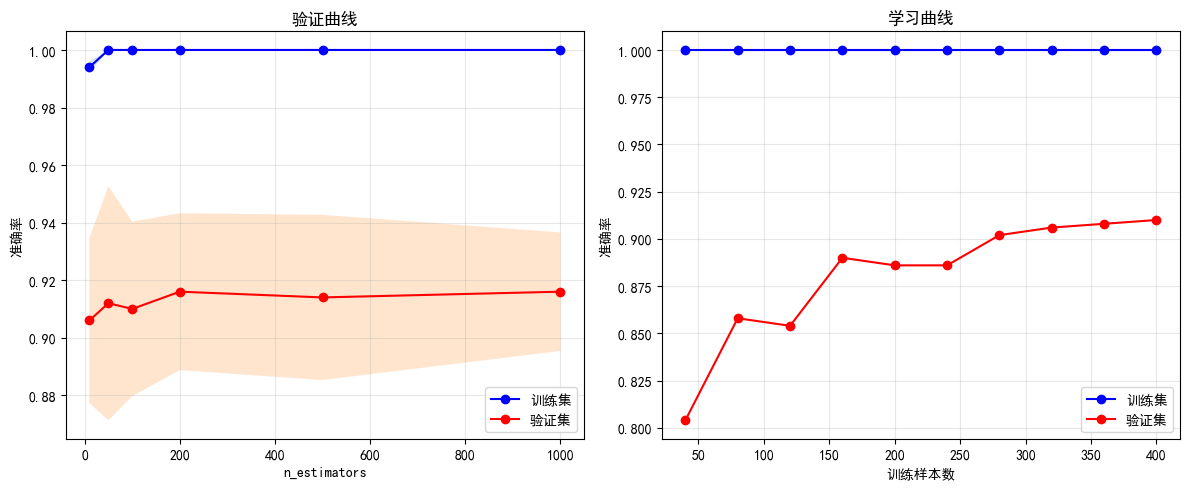

In [25]:
from sklearn.model_selection import validation_curve, learning_curve

print("学习曲线与验证曲线")

# 验证曲线：观察单个参数对性能的影响
param_range = [10, 50, 100, 200, 500, 1000]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X, y,
    param_name='n_estimators',
    param_range=param_range,
    cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(12, 5))

# 验证曲线
plt.subplot(1, 2, 1)
plt.plot(param_range, train_mean, 'o-', label='训练集', color='blue') # 使用蓝色实线表示训练集得分
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2) # 半透明色块填充标准差的波动范围
plt.plot(param_range, val_mean, 'o-', label='验证集', color='red') # 红色实线表示验证集得分
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel('n_estimators')
plt.ylabel('准确率')
plt.title('验证曲线')
plt.legend()
plt.grid(True, alpha=0.3)

# 学习曲线
plt.subplot(1, 2, 2)
# learning_curve，将数据量从 10% 逐步递增到 100%（分 10 个梯度），同样采用 5 折交叉验证评估得分
train_sizes, train_scores_lc, val_scores_lc = learning_curve( 
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean_lc = train_scores_lc.mean(axis=1)
val_mean_lc = val_scores_lc.mean(axis=1)

plt.plot(train_sizes, train_mean_lc, 'o-', label='训练集', color='blue')
plt.plot(train_sizes, val_mean_lc, 'o-', label='验证集', color='red')
plt.xlabel('训练样本数')
plt.ylabel('准确率')
plt.title('学习曲线')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

** 左图：验证曲线（Validation Curve）诊断**
1. 观察现象：
- 蓝线（训练集）：准确率几乎瞬间达到 1.00 (100%)。这意味着无论树的数量（n_estimators）是多少，模型都能完美地“记住”训练数据。
- 红线（验证集）：准确率在 0.92 左右徘徊，且随着参数增加并没有显著提升，甚至略有波动。
- 差距（Gap）：蓝线和红线之间存在明显的、稳定的差距（约 8%）。
2. 结论：典型的过拟合（Overfitting），但已趋于稳定。
- 模型复杂度已经足够高（甚至过高），能够完全拟合训练数据。
- 增加 n_estimators（树的个数）对提升泛化能力帮助不大，因为瓶颈不在于树不够多，而在于模型可能学到了训练集中的噪声或特定模式，导致无法迁移到验证集。
- 建议：不需要再增加 n_estimators 了（比如 50 和 1000 效果差不多）。如果想提升红线，应该尝试限制单棵树的深度（max_depth）或增加正则化，而不是增加树的数量。
- 
**右图：学习曲线（Learning Curve）诊断**
1. 观察现象：
- 蓝线（训练集）：始终维持在 1.00。这再次印证了模型极其强大，哪怕只有很少的数据（如 50 个样本），它也能做到 100% 正确。
- 红线（验证集）：
   - 在数据量较少（50-100）时，分数较低且波动大（这是正常的，因为数据少，方差大）。
   - 随着数据量增加到 150 以上，分数上升并稳定在 0.90 - 0.91 之间。
   - 关键点：在 250 个样本之后，曲线似乎进入了平台期（Plateau），虽然还在微弱上升，但幅度很小。
2. 结论：数据量可能已经接近饱和，或者遇到了“贝叶斯误差”。
- 不是欠拟合：如果欠拟合，两条线都会很低。这里蓝线很高，说明模型学习能力没问题。
- 数据增益递减：从 300 到 400 样本，性能提升非常有限。这意味着单纯靠“堆数据”来提升准确率的边际效益正在降低。
- 潜在问题：验证集卡在 0.91 上不去，而训练集是 1.0。这说明剩下的 ~9% 的错误，可能是由于特征不足（模型找不到区分依据）或者标签噪声（数据本身标错了）导致的。

如何突破瓶颈（提升那 9% 的差距）？既然加树（左图）和加数据（右图趋势变缓）的效果都不明显，可以尝试特征工程、限制模型复杂度或者检查一下数据质量。

总结：
如果把调参比作看病，前面的贝叶斯优化像是“开药方”，而这段代码就是做“心电图和B超”。它不直接改变模型，而是提供直观的医学影像，让你清楚地知道模型现在的健康状况（偏差-方差权衡），从而决定是该加正则化、减少复杂度，还是该去多采集一些训练数据。

---

## 八、综合实战：手写数字识别调优

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [26]:
print("综合实战：手写数字识别超参数调优")

from sklearn.datasets import load_digits

# 加载数据
digits = load_digits()
X_d, y_d = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集: {X_train_scaled.shape}")
print(f"测试集: {X_test_scaled.shape}")

# 基准模型（默认参数）
print("\n基准模型性能:")
print("-" * 40)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_scaled, y_train)
baseline_score = rf_baseline.score(X_test_scaled, y_test)
print(f"默认参数测试准确率: {baseline_score:.4f}")


综合实战：手写数字识别超参数调优
训练集: (1437, 64)
测试集: (360, 64)

基准模型性能:
----------------------------------------
默认参数测试准确率: 0.9639


基准线有了，开始用随机搜索调参：


In [11]:
# 随机搜索调优
print("\n随机搜索调优:")
print("-" * 40)

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    rf, param_dist, n_iter=30, cv=5,
    scoring='accuracy', n_jobs=-1,
    random_state=42, verbose=1
)

random_search.fit(X_train_scaled, y_train)

print(f"\n最优参数:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n交叉验证最优得分: {random_search.best_score_:.4f}")

# 测试集评估
best_model = random_search.best_estimator_
tuned_score = best_model.score(X_test_scaled, y_test)
print(f"调优后测试准确率: {tuned_score:.4f}")
print(f"\n性能提升: {(tuned_score - baseline_score) * 100:.2f}%")



随机搜索调优:
----------------------------------------
Fitting 5 folds for each of 30 candidates, totalling 150 fits

最优参数:
  max_depth: 15
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 3
  n_estimators: 137

交叉验证最优得分: 0.9756
调优后测试准确率: 0.9722

性能提升: 0.83%


调优完成！我们来画图全方位可视化随机搜索（Random Search）的调参结果。

- 左上角图1：n_estimators 对性能的影响（散点图）， 筛选出 max_depth 等于最优值的数据，然后画出 n_estimators（树的数量）与交叉验证准确率的关系。
- 右上角图2：max_depth 对性能的影响（柱状图），筛选出 n_estimators 等于最优值的数据，按 max_depth（树的最大深度）分组计算平均准确率，并画成柱状图。
- 左下角图3：搜索过程中的最优值变化（折线图），使用 cummax() 计算累积最大值。这意味着只要出现一个新的最高分，线就会上升；如果没有打破记录，线就保持水平。
- 右下角图4：参数组合得分分布（直方图），统计所有尝试过的参数组合的得分频率，并标出最终的最优得分（红线）。

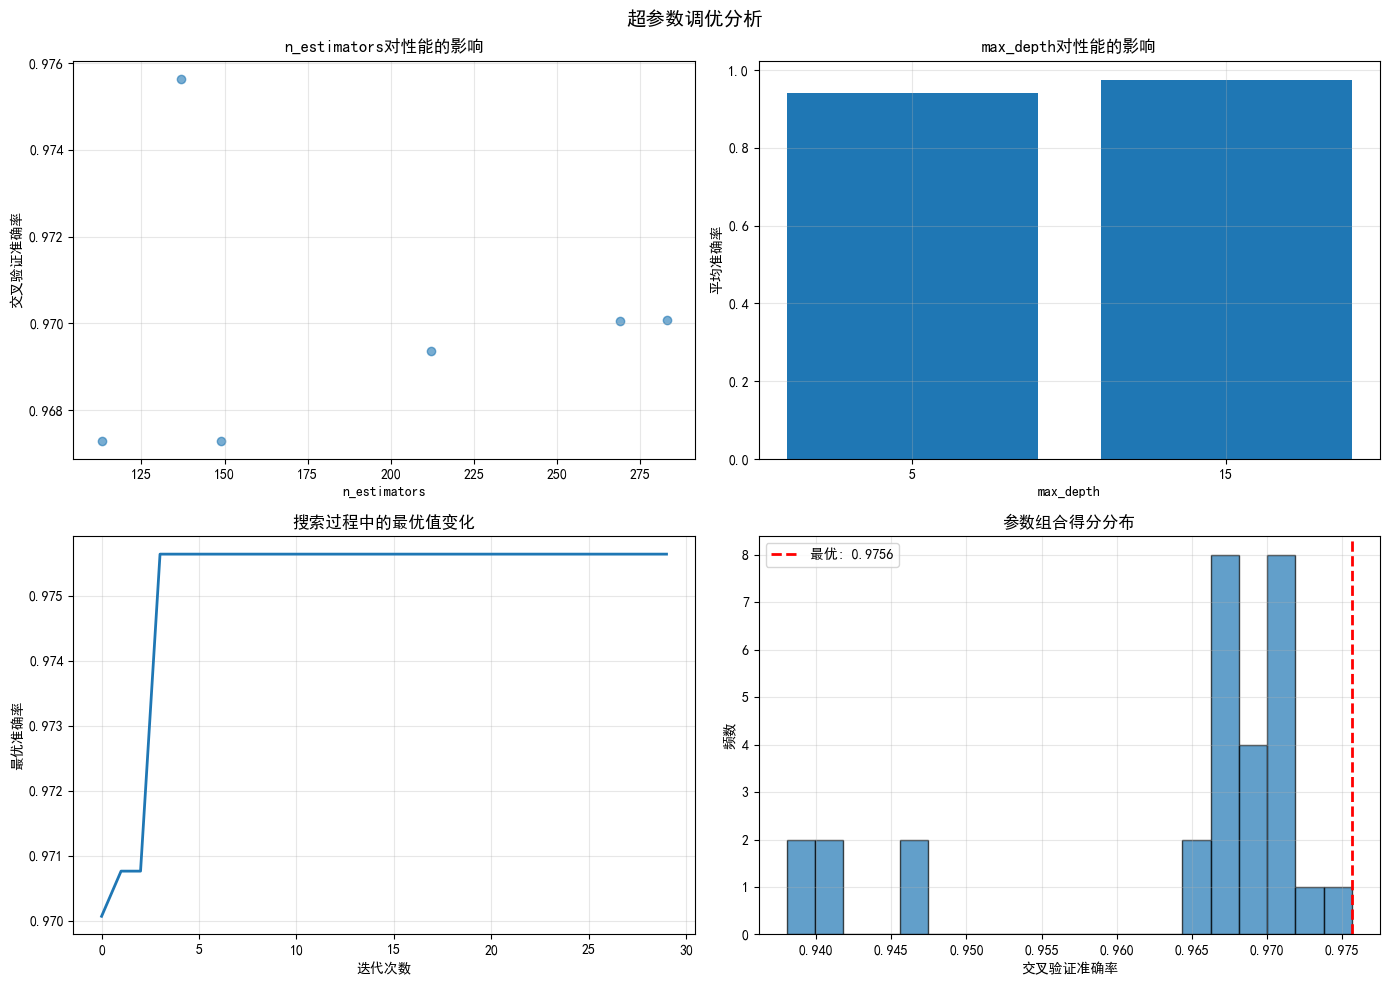

In [12]:
# 可视化调优过程
results = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# n_estimators影响
ax1 = axes[0, 0]
results_plot = results[results['param_max_depth'] == random_search.best_params_['max_depth']]
ax1.scatter(results_plot['param_n_estimators'], results_plot['mean_test_score'], alpha=0.6)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('交叉验证准确率')
ax1.set_title('n_estimators对性能的影响')
ax1.grid(True, alpha=0.3)

# max_depth影响
ax2 = axes[0, 1]
results_plot = results[results['param_n_estimators'] == random_search.best_params_['n_estimators']]
depth_scores = results_plot.groupby('param_max_depth')['mean_test_score'].mean()
ax2.bar(range(len(depth_scores)), depth_scores.values)
ax2.set_xticks(range(len(depth_scores)))
ax2.set_xticklabels([str(d) for d in depth_scores.index])
ax2.set_xlabel('max_depth')
ax2.set_ylabel('平均准确率')
ax2.set_title('max_depth对性能的影响')
ax2.grid(True, alpha=0.3)

# 迭代过程中的最优值
ax3 = axes[1, 0]
cumulative_best = results['mean_test_score'].cummax()
ax3.plot(cumulative_best, linewidth=2)
ax3.set_xlabel('迭代次数')
ax3.set_ylabel('最优准确率')
ax3.set_title('搜索过程中的最优值变化')
ax3.grid(True, alpha=0.3)

# 所有尝试的得分分布
ax4 = axes[1, 1]
ax4.hist(results['mean_test_score'], bins=20, edgecolor='black', alpha=0.7)
ax4.axvline(random_search.best_score_, color='red', linestyle='--', 
           linewidth=2, label=f'最优: {random_search.best_score_:.4f}')
ax4.set_xlabel('交叉验证准确率')
ax4.set_ylabel('频数')
ax4.set_title('参数组合得分分布')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('超参数调优分析', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_tuning_analysis.png', dpi=150)
plt.show()


解读：
1. n_estimators 对性能的影响（左上）：散点图显示，当 n_estimators（树的数量）在 100 到 150 之间时，出现了一个明显的最高点（约 0.976）。随着树的数量继续增加（200, 275），准确率反而略微下降并趋于平稳（约 0.970）。通常认为树越多越好，但这里出现了反常。这可能是因为数据量较小或特征较少，过多的树导致了过拟合的累积，或者仅仅是随机森林的随机性导致的波动。说明维持在 100-150 之间可能是性价比最高的选择（训练更快，效果最好）
2. max_depth 对性能的影响 (右上)：柱状图只显示了两个柱子，分别对应深度 5 和 15，且两者的平均准确率都非常高（接近 1.0，看起来像是 0.95+。说明在随机搜索范围内，可能只尝试了这两个深度值，或者只有这两个深度被选中了。无论树是深（15）还是浅（5），模型都能保持极高的性能。这意味着模型对深度的敏感度不高，或者说在这个数据集上，简单的规则（深度5）就已经足够捕捉大部分规律了。通常优先选深度 5，因为模型更简单，解释性更强，且不易过拟合。
3. 搜索过程中的最优值变化 (左下)：曲线在第 3 到第 4 次迭代时就迅速攀升到了最高点（约 0.9756），随后的 20 多次迭代中，曲线一直保持水平，没有再突破这个记录。这是一个非常典型的“早停”信号。说明随机搜索在前几轮就“撞大运”找到了全局最优解（或非常接近全局最优的区域）。后面的 25 次迭代基本上是在做“无用功”，虽然它们验证了当前结果的稳定性，但没有带来性能提升。
4. 参数组合得分分布 (右下)：直方图显示绝大多数尝试的参数组合得分都集中在 0.965 - 0.972 之间。红色的虚线（最优值 0.9756）位于分布的最右侧边缘。即使是“较差”的参数组合，准确率也能达到 0.94 以上。这说明该数据集对于随机森林算法来说相对容易，或者特征质量很高。分数分布非常集中（方差小），说明模型的性能已经触及了“天花板”。想要从 0.975 提升到 0.980 会非常困难，可能需要更换算法或进行更精细的特征工程，而不是单纯调参。

整体而言，模型处于极佳的状态，交叉验证准确率稳定在 97.5% 左右。参数选择： 最终选定的参数应该是 n_estimators 约为 140 左右，max_depth 为 5 或 15 均可（推荐尝试 5 以简化模型）。如此高的分数，建议检查一下是否存在数据泄露（例如某些特征直接包含了标签信息），或者确认测试集是否真的具有代表性。

---

## 九、调参最佳实践

调参是有套路的，来学一学：

1. 先确定评估指标
   • 准确率？F1？AUC？根据业务场景选择

2. 划分数据
   • 训练集：用于训练模型
   • 验证集：用于调参（交叉验证）
   • 测试集：最终评估（只用一次！）

3. 调参策略
   • 先粗调：大范围随机搜索
   • 再细调：在好参数附近网格搜索
   • 或直接用贝叶斯优化

4. 避免过拟合验证集
   • 交叉验证减少方差
   • 嵌套交叉验证（训练/验证/测试三层）

5. 常见参数调优顺序
   RandomForest:
   • n_estimators: 先设大值（如200），固定后调其他
   • max_depth: 控制过拟合
   • min_samples_split/leaf: 进一步正则化

   SVM:
   • C: 正则化强度
   • gamma/kernel: 非线性程度

   神经网络:
   • learning_rate: 最重要
   • batch_size: 其次
   • 网络结构: 最后

6. 自动化工具
   • Optuna: 更先进的贝叶斯优化
   • Hyperopt: 分布式超参优化
   • AutoML: 全自动调参

---

## 十、小结

| 方法 | 原理 | 优点 | 缺点 |
|------|------|------|------|
| **网格搜索** | 穷举所有组合 | 找到全局最优 | 计算量大 |
| **随机搜索** | 随机采样 | 快，适合大空间 | 可能错过最优 |
| **贝叶斯优化** | 智能引导 | 效率最高 | 实现复杂 |

**交叉验证要点**：
- 类别不平衡用StratifiedKFold
- K=5或10最常用
- 交叉验证评估，独立测试集最终验证

---

## 十一、课后练习

1. 对SVM进行超参数调优（C和gamma）
2. 比较不同K值对交叉验证结果的影响
3. 尝试用不同的评分指标（F1、AUC）进行调优
4. 画出你调参模型的学习曲线，判断是否过拟合

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
X, y = make_classification(n_samples=500, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ============================================================
# 练习1：对SVM进行超参数调优（C和gamma），用GridSearchCV
# ============================================================
print("=" * 60)
print("练习1：SVM超参数调优（C × gamma 网格搜索）")
print("=" * 60)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

print(f"\n搜索空间: C={param_grid['C']}, gamma={param_grid['gamma']}")
print(f"总组合数: {len(param_grid['C']) * len(param_grid['gamma'])}")

grid_search = GridSearchCV(SVC(kernel='rbf', random_state=42),
                           param_grid, cv=5, scoring='accuracy',
                           return_train_score=True, n_jobs=-1)
grid_search.fit(X_train_s, y_train)

print(f"\n最佳参数: C={grid_search.best_params_['C']}, gamma={grid_search.best_params_['gamma']}")
print(f"最佳交叉验证得分: {grid_search.best_score_:.4f}")
print(f"测试集得分: {grid_search.score(X_test_s, y_test):.4f}")

# Top 5参数组合
print(f"\nTop 5 参数组合:")
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.nlargest(5, 'mean_test_score')
for i, row in top5.iterrows():
    print(f"  C={row['param_C']:>6}, gamma={row['param_gamma']:>6}: "
          f"CV均值={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")

# 可视化：C×gamma热力图
scores_matrix = cv_results.pivot_table(index='param_gamma', columns='param_C',
                                        values='mean_test_score')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(scores_matrix, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('练习1 - SVM C×gamma 交叉验证得分热力图', fontsize=14)
ax.set_xlabel('C', fontsize=12)
ax.set_ylabel('gamma', fontsize=12)
plt.tight_layout()
plt.close()

练习1：SVM超参数调优（C × gamma 网格搜索）

搜索空间: C=[0.01, 0.1, 1, 10, 100], gamma=[0.001, 0.01, 0.1, 1, 10]
总组合数: 25

最佳参数: C=10, gamma=0.1
最佳交叉验证得分: 0.9229
测试集得分: 0.9333

Top 5 参数组合:
  C=  10.0, gamma=   0.1: CV均值=0.9229 ± 0.0232
  C= 100.0, gamma=   0.1: CV均值=0.9229 ± 0.0232
  C=   1.0, gamma=   0.1: CV均值=0.9200 ± 0.0368
  C=  10.0, gamma=  0.01: CV均值=0.8943 ± 0.0321
  C= 100.0, gamma=  0.01: CV均值=0.8714 ± 0.0338


In [2]:
# ============================================================
# 练习2：比较不同K值（3,5,10）对交叉验证结果的影响
# ============================================================
print("\n" + "=" * 60)
print("练习2：不同折数K对交叉验证结果的影响")
print("=" * 60)

best_model = grid_search.best_estimator_
cv_folds = [3, 5, 10]

for k in cv_folds:
    scores = cross_val_score(best_model, X_train_s, y_train, cv=k)
    print(f"\n  {k}折交叉验证:")
    print(f"    各折得分: {[f'{s:.4f}' for s in scores]}")
    print(f"    均值: {scores.mean():.4f}, 标准差: {scores.std():.4f}")

# 用最佳参数在不同K值下做网格搜索
print(f"\n在不同折数下做完整网格搜索:")
for k in cv_folds:
    gs = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=k, n_jobs=-1)
    gs.fit(X_train_s, y_train)
    print(f"  {k}折: 最佳参数 C={gs.best_params_['C']}, gamma={gs.best_params_['gamma']}, "
          f"最佳CV得分={gs.best_score_:.4f}, 测试得分={gs.score(X_test_s, y_test):.4f}")


练习2：不同折数K对交叉验证结果的影响

  3折交叉验证:
    各折得分: ['0.9316', '0.8974', '0.9397']
    均值: 0.9229, 标准差: 0.0183

  5折交叉验证:
    各折得分: ['0.9286', '0.9143', '0.8857', '0.9571', '0.9286']
    均值: 0.9229, 标准差: 0.0232

  10折交叉验证:
    各折得分: ['0.9714', '0.9143', '0.9429', '0.8571', '0.9429', '0.8286', '0.9714', '0.9429', '0.9429', '0.9429']
    均值: 0.9257, 标准差: 0.0446

在不同折数下做完整网格搜索:
  3折: 最佳参数 C=1, gamma=0.1, 最佳CV得分=0.9287, 测试得分=0.9267
  5折: 最佳参数 C=10, gamma=0.1, 最佳CV得分=0.9229, 测试得分=0.9333
  10折: 最佳参数 C=1, gamma=0.1, 最佳CV得分=0.9314, 测试得分=0.9267


In [3]:

# ============================================================
# 练习3：用不同的评分指标（F1、AUC）进行调优
# ============================================================
print("\n" + "=" * 60)
print("练习3：不同评分指标对调优结果的影响")
print("=" * 60)

scoring_metrics = ['accuracy', 'f1', 'roc_auc']

for metric in scoring_metrics:
    gs = GridSearchCV(SVC(kernel='rbf', probability=(metric == 'roc_auc'), random_state=42),
                      param_grid, cv=5, scoring=metric, n_jobs=-1)
    gs.fit(X_train_s, y_train)
    print(f"\n  评分指标: {metric}")
    print(f"    最佳参数: C={gs.best_params_['C']}, gamma={gs.best_params_['gamma']}")
    print(f"    最佳CV得分({metric}): {gs.best_score_:.4f}")
    print(f"    测试集准确率: {gs.score(X_test_s, y_test):.4f}")


练习3：不同评分指标对调优结果的影响

  评分指标: accuracy
    最佳参数: C=10, gamma=0.1
    最佳CV得分(accuracy): 0.9229
    测试集准确率: 0.9333

  评分指标: f1
    最佳参数: C=10, gamma=0.1
    最佳CV得分(f1): 0.9245
    测试集准确率: 0.9367

  评分指标: roc_auc
    最佳参数: C=10, gamma=0.1
    最佳CV得分(roc_auc): 0.9664
    测试集准确率: 0.9766



练习4：学习曲线分析（过拟合判断）

训练集大小 | 训练得分 | 测试得分 | 差距
---------------------------------------------
    28      | 1.0000   | 0.7886   | 0.2114
    56      | 1.0000   | 0.8200   | 0.1800
    84      | 1.0000   | 0.8514   | 0.1486
   112      | 1.0000   | 0.8743   | 0.1257
   140      | 1.0000   | 0.8829   | 0.1171
   168      | 1.0000   | 0.9171   | 0.0829
   196      | 1.0000   | 0.9000   | 0.1000
   224      | 1.0000   | 0.9171   | 0.0829
   252      | 1.0000   | 0.9229   | 0.0771
   280      | 1.0000   | 0.9229   | 0.0771

过拟合判断: 训练-测试差距 = 0.0771
  结论: 存在轻微过拟合


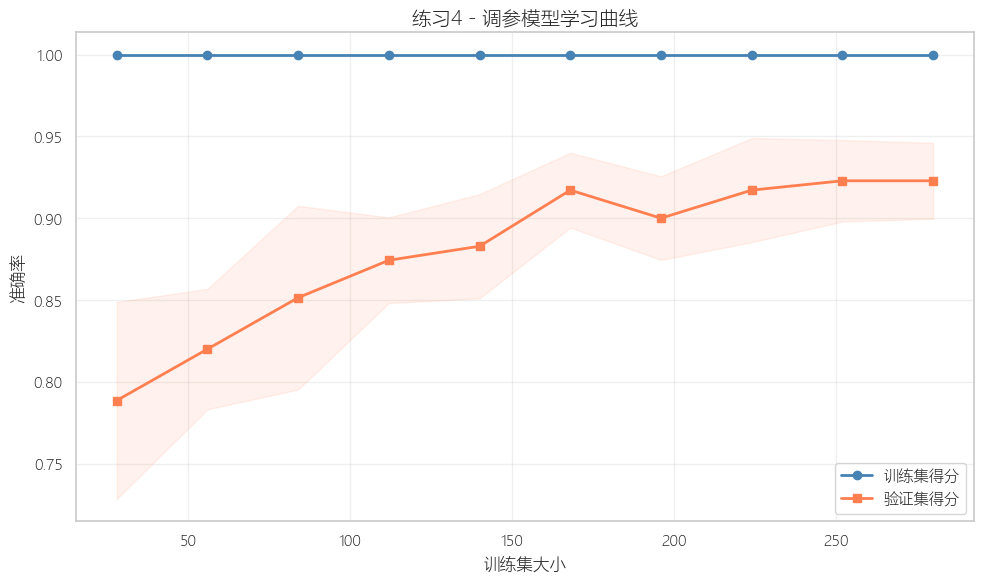

In [4]:
# ============================================================
# 练习4：画出调参模型的学习曲线，判断是否过拟合
# ============================================================
print("\n" + "=" * 60)
print("练习4：学习曲线分析（过拟合判断）")
print("=" * 60)

train_sizes_list = np.linspace(0.1, 1.0, 10)
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, X_train_s, y_train,
    train_sizes=train_sizes_list, cv=5, n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

print(f"\n训练集大小 | 训练得分 | 测试得分 | 差距")
print("-" * 45)
for size, tr, te in zip(train_sizes, train_mean, test_mean):
    print(f"  {int(size):>4d}      | {tr:.4f}   | {te:.4f}   | {tr-te:.4f}")

gap = train_mean[-1] - test_mean[-1]
print(f"\n过拟合判断: 训练-测试差距 = {gap:.4f}")
if gap < 0.05:
    print("  结论: 模型拟合良好，没有明显过拟合")
elif gap < 0.1:
    print("  结论: 存在轻微过拟合")
else:
    print("  结论: 存在明显过拟合，需要简化模型或增加数据")

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='coral')
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', linewidth=2, markersize=6, label='训练集得分')
ax.plot(train_sizes, test_mean, 's-', color='coral', linewidth=2, markersize=6, label='验证集得分')
ax.set_title('练习4 - 调参模型学习曲线', fontsize=14)
ax.set_xlabel('训练集大小', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 55 篇：K-Means 聚类 — 无监督学习入门**
>
> 下篇进入无监督学习——K-Means 聚类，不需要标签就能自动发现数据中的群组，是客户分群、异常检测的利器。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*